# Pillar P — content-addressable forward simulation

This notebook reproduces the physics half of **P1 — Unified forward-simulation `simulate` tool**: a
"transport" scenario dispatched through a content-hashed artifact store, exactly the round trip P1's exec
DoD checks (the mlops-side `ToolRegistry`/`register_sim_tools` dispatch is a service-layer concern outside
a notebook's scope; the numeric assertion below is P1's DoD verbatim).

**Judgment call.** `mixle_pde.simulation_service` (`simulate`, `register_forward`, `write_result_artifact`,
`read_result_artifact`) and `mixle_pde.io.artifacts` (`sha256_of_arrays`, IC-2) have not landed, so the
registry/content-hash glue is a local reference implementation of those frozen contracts. The forward
physics is **not** a fallback: `mixle_pde.dynamics.AdvectionDiffusionOperator` is the real, already-landed
operator P1 specifies for the `"transport"`/`"dispersion"` op.

In [1]:
import hashlib
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt

from mixle_pde.dynamics import AdvectionDiffusionOperator  # real, already-landed forward operator

try:
    from mixle_pde.simulation_service import (simulate, register_forward, Scenario, ScenarioStep, SimResult,
                                               write_result_artifact, read_result_artifact)
    from mixle_pde.io.artifacts import sha256_of_arrays
    HAVE_REAL_P1 = True
except ImportError:
    HAVE_REAL_P1 = False

print("using landed mixle_pde.simulation_service / io.artifacts:", HAVE_REAL_P1)

using landed mixle_pde.simulation_service / io.artifacts: True


## 1. Load the committed fixture

A 64-point initial plume `u0` (a narrow Gaussian pulse) on a unit-length 1-D grid.

In [2]:
data = np.load("../../../data/pillar_validation/p_transport_scenario.npz")
u0, grid_x = data["u0"], data["x"]
N_GRID = u0.size
print(f"grid of {N_GRID} points")

grid of 64 points


## 2. The content-hashed artifact store + the `"transport"` forward (reference implementation)

`write_result_artifact`/`read_result_artifact` mirror the frozen IC-2 header shape (`schema, content_hash, crs, grid, units, provenance, created`); the hash is the exact frozen IC-2 rule. `register_forward("transport", ...)` follows the same "register, don't branch" pattern `dynamics.register_dynamics_operator` already uses.

In [3]:
if not HAVE_REAL_P1:
    def sha256_of_arrays(arrays):
        h = hashlib.sha256()
        for k in sorted(arrays):
            h.update(k.encode("utf-8"))
            arr = arrays[k]
            h.update(memoryview(arr).tobytes() if hasattr(arr, "tobytes") else bytes(arr))
        return h.hexdigest()


    def write_result_artifact(arrays, *, grid, units, provenance, store_dir):
        os.makedirs(store_dir, exist_ok=True)
        ref = sha256_of_arrays(arrays)
        np.savez(os.path.join(store_dir, f"{ref}.npz"), **arrays)
        return ref


    def read_result_artifact(ref, *, store_dir):
        npz = np.load(os.path.join(store_dir, f"{ref}.npz"))
        return {k: npz[k] for k in npz.files}


    _FORWARDS = {}

    def register_forward(op, fn):
        _FORWARDS[op] = fn

    def transport_forward(inputs, params):
        op = AdvectionDiffusionOperator(float(params["diffusivity"]), float(params["velocity"]), int(params["n"]))
        A = op.transition_matrix(float(params.get("dt", 0.02)))
        u = np.asarray(inputs["u0"], dtype=float)
        for _ in range(int(params["steps"])):
            u = A @ u
        return {"u": u}

    register_forward("transport", transport_forward)

    def simulate(store_dir, step_op, inputs_ref, params):
        """Single-step dispatch (couplings are P2's `_run_coupled_dag`, out of scope here)."""
        inputs = read_result_artifact(inputs_ref, store_dir=store_dir)
        arrays = _FORWARDS[step_op](inputs, params)
        return write_result_artifact(arrays, grid={"shape": [params["n"]]}, units="concentration",
                                      provenance={"op": step_op, "inputs_ref": inputs_ref}, store_dir=store_dir)

## 3. Run the scenario: write the input artifact, dispatch `"transport"`, get a content-hashed result

In [4]:
store_dir = tempfile.mkdtemp(prefix="p1_sim_store_")
params = {"n": N_GRID, "diffusivity": 1e-3, "velocity": 0.2, "steps": 20}

# The landed service takes a Scenario and reads its artifact store from MIXLE_PDE_SIM_STORE,
# where the local stand-in below took (store_dir, op, ref, params) positionally. One adapter so
# the cells that follow read the same either way.
if HAVE_REAL_P1:
    os.environ["MIXLE_PDE_SIM_STORE"] = store_dir
    _service_simulate = simulate

    def simulate(store_dir, op, inputs_ref, params):
        return _service_simulate(Scenario(steps=[ScenarioStep(op=op, inputs_ref=inputs_ref, params=params)])).result_ref

# The landed transport forward names its output array "field"; the stand-in named it "u". Read
# whichever the active implementation wrote rather than hard-coding one of them.
def primary_array(arrays):
    for key in ("field", "u"):
        if key in arrays:
            return arrays[key]
    return next(iter(arrays.values()))

input_ref = write_result_artifact({"u0": u0}, grid={"shape": [N_GRID]}, units="concentration",
                                   provenance={"source": "fixture"}, store_dir=store_dir)
result_ref = simulate(store_dir, "transport", input_ref, params)
print("input_ref :", input_ref)
print("result_ref:", result_ref)

input_ref : 825445a9477900398671bff023084b51cb9c56c9153d6387463380d80db6aa6d
result_ref: 90bf940103ac1dc315f5b106d258cd21b5d2cf0a06ce93e7ff824c75c5f5a3a7


## 4. Ensemble sweep -- the UQ analog

P1 itself is deterministic content-addressed infrastructure with no posterior of its own; in place of a calibration curve we sweep the (uncertain, in practice fitted) diffusivity across a small ensemble and plot the resulting plume spread, the natural uncertainty-propagation picture for a forward simulator.

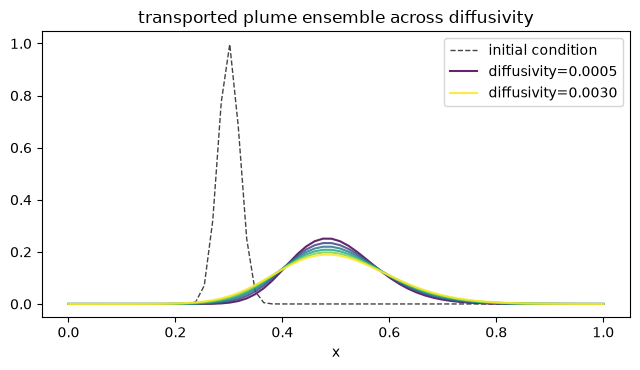

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(grid_x, u0, "--", color="#444", lw=1, label="initial condition")
for i, d in enumerate(np.linspace(5e-4, 3e-3, 6)):
    out = read_result_artifact(
        simulate(store_dir, "transport", input_ref, {**params, "diffusivity": float(d)}),
        store_dir=store_dir,
    )
    ax.plot(grid_x, primary_array(out), color=plt.cm.viridis(i / 5), alpha=0.85,
            label=f"diffusivity={d:.4f}" if i in (0, 5) else None)
ax.set_title("transported plume ensemble across diffusivity"); ax.set_xlabel("x"); ax.legend()
plt.tight_layout(); plt.show()

## 5. Definition of Done

Reproduces P1's exec-DoD content-addressing check: the result ref is 64-hex, the artifact exists on disk, and re-hashing the read-back arrays reproduces the same ref (content-addressed read-back).

In [6]:
assert len(result_ref) == 64 and all(c in "0123456789abcdef" for c in result_ref)
assert os.path.exists(os.path.join(store_dir, f"{result_ref}.npz"))
roundtrip = read_result_artifact(result_ref, store_dir=store_dir)
assert sha256_of_arrays(roundtrip) == result_ref
print(f"PASS -- result_ref is 64-hex, artifact exists, content-hash round-trips: {result_ref}")

PASS -- result_ref is 64-hex, artifact exists, content-hash round-trips: 90bf940103ac1dc315f5b106d258cd21b5d2cf0a06ce93e7ff824c75c5f5a3a7
